# Improved IDS: Quality-Aware CVAE + AE-LSTM-Attention

**Base Paper:** Susilo et al. (2025) — *Intelligent Intrusion Detection System Against Various Attacks Based on a Hybrid Deep Learning Algorithm*

**Improvements Implemented:**
1. **Quality-Aware CVAE Augmentation** — Replaces SMOTE. A Conditional Variational Autoencoder generates synthetic samples for minority classes, and each sample is filtered by reconstruction error before being admitted to training. Only samples whose reconstruction error falls below a learned per-class threshold τ are kept.
2. **AE-LSTM + Attention** — Replaces the CNN head. The concatenated outputs of the AE decoder and LSTM are passed into a Scaled Dot-Product Attention layer, which dynamically weights the most discriminative features before final classification.

**Dataset:** CICIoT2023 (same as base paper)  
**Framework:** PyTorch (T4 GPU on Kaggle)  
**Split:** 70 / 30 train-test, consistent with base paper

## Step 1 — Install Dependencies

In [13]:
!pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn torch -q

## Step 2 — Imports & Reproducibility Seed

In [14]:
import os, random, json, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Step 3 — Dataset Paths

In [15]:
# ── Verify input paths ──────────────────────────────────────────────────
print('Contents of /kaggle/input:')
for root, dirs, files in os.walk('/kaggle/input'):
    depth = root.replace('/kaggle/input', '').count(os.sep)
    if depth > 3:
        continue
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    if depth <= 2:
        for f in files[:5]:
            size_mb = os.path.getsize(os.path.join(root, f)) / 1e6
            print(f'{indent}  {f}  ({size_mb:.1f} MB)')
        if len(files) > 5:
            print(f'{indent}  ... and {len(files)-5} more')

Contents of /kaggle/input:
input/
  datasets/
    himadri07/
      ciciot2023/


In [16]:
# ── Set these to match your Kaggle dataset path ──────────────────────────
TRAIN_DIR = '/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train'
TEST_DIR  = '/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/test'
VAL_DIR   = '/kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/validation'

for name, d in [('train', TRAIN_DIR), ('test', TEST_DIR), ('val', VAL_DIR)]:
    n = len(glob.glob(os.path.join(d, '*.csv')))
    print(f'{name:>6}  ->  {d}  ({n} CSV files)')

 train  ->  /kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/train  (1 CSV files)
  test  ->  /kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/test  (1 CSV files)
   val  ->  /kaggle/input/datasets/himadri07/ciciot2023/CICIOT23/validation  (1 CSV files)


## Step 4 — Load & Combine All CSVs

In [18]:
def load_folder(folder_path):
    files = sorted(glob.glob(os.path.join(folder_path, '*.csv')))
    if not files:
        print(f'  WARNING: No CSVs in {folder_path}')
        return pd.DataFrame()
    parts = []
    for f in files:
        tmp = pd.read_csv(f, low_memory=False)
        parts.append(tmp)
        print(f'  {os.path.basename(f):40s}  {tmp.shape}')
    return pd.concat(parts, ignore_index=True)

print('Loading TRAIN ...')
df_tr = load_folder(TRAIN_DIR)
print(f'=> {df_tr.shape}')

print('\nLoading TEST ...')
df_te = load_folder(TEST_DIR)
print(f'=> {df_te.shape}')

print('\nLoading VALIDATION ...')
df_va = load_folder(VAL_DIR)
print(f'=> {df_va.shape}')

df_raw = pd.concat([df_tr, df_te, df_va], ignore_index=True)
print(f'\nCombined shape: {df_raw.shape}')

Loading TRAIN ...
  train.csv                                 (5491971, 47)
=> (5491971, 47)

Loading TEST ...
  test.csv                                  (1176851, 47)
=> (1176851, 47)

Loading VALIDATION ...
  validation.csv                            (1176851, 47)
=> (1176851, 47)

Combined shape: (7845673, 47)


## Step 5 — Identify Label Column

In [19]:
label_col = None
for col in ['label', 'Label', 'Attack_type', 'attack_type', 'class', 'Class']:
    if col in df_raw.columns:
        label_col = col
        break

print(f'Label column: [{label_col}]')
print(f'Unique raw labels ({df_raw[label_col].nunique()}):')
print(df_raw[label_col].value_counts().to_string())

Label column: [label]
Unique raw labels (34):
label
DDoS-ICMP_Flood            1210546
DDoS-UDP_Flood              910741
DDoS-TCP_Flood              756122
DDoS-PSHACK_Flood           687565
DDoS-SYN_Flood              683505
DDoS-RSTFINFlood            678823
DDoS-SynonymousIP_Flood     603358
DoS-UDP_Flood               557495
DoS-TCP_Flood               448927
DoS-SYN_Flood               339804
BenignTraffic               184766
Mirai-greeth_flood          165977
Mirai-udpplain              149664
Mirai-greip_flood           126967
DDoS-ICMP_Fragmentation      75878
MITM-ArpSpoofing             51897
DDoS-UDP_Fragmentation       48614
DDoS-ACK_Fragmentation       48067
DNS_Spoofing                 30349
Recon-HostDiscovery          22550
Recon-OSScan                 16520
Recon-PortScan               13813
DoS-HTTP_Flood               12125
VulnerabilityScan             6214
DDoS-HTTP_Flood               4786
DDoS-SlowLoris                3999
DictionaryBruteForce          2150
Bro

## Step 6 — Map 33 Labels → 8 Classes (same as base paper)

In [20]:
LABEL_MAP = {
    'BenignTraffic':            'Benign',
    # DDoS
    'DDoS-RSTFINFlood':         'DDoS Attack',
    'DDoS-PSHACK_Flood':        'DDoS Attack',
    'DDoS-SYN_Flood':           'DDoS Attack',
    'DDoS-UDP_Flood':           'DDoS Attack',
    'DDoS-TCP_Flood':           'DDoS Attack',
    'DDoS-ICMP_Flood':          'DDoS Attack',
    'DDoS-HTTP_Flood':          'DDoS Attack',
    'DDoS-SlowLoris':           'DDoS Attack',
    'DDoS-ICMP_Fragmentation':  'DDoS Attack',
    'DDoS-UDP_Fragmentation':   'DDoS Attack',
    'DDoS-ACK_Fragmentation':   'DDoS Attack',
    # DoS
    'DoS-UDP_Flood':            'DoS Attack',
    'DoS-SYN_Flood':            'DoS Attack',
    'DoS-TCP_Flood':            'DoS Attack',
    'DoS-HTTP_Flood':           'DoS Attack',
    # Mirai
    'Mirai-greeth_flood':       'Mirai Attack',
    'Mirai-greip_flood':        'Mirai Attack',
    'Mirai-udpplain':           'Mirai Attack',
    # Recon
    'Recon-PingSweep':          'Recon Attack',
    'Recon-OSScan':             'Recon Attack',
    'Recon-PortScan':           'Recon Attack',
    'VulnerabilityScan':        'Recon Attack',
    'Recon-HostDiscovery':      'Recon Attack',
    # Spoofing
    'DNS_Spoofing':             'Spoofing Attack',
    'MITM-ArpSpoofing':         'Spoofing Attack',
    # Brute Force
    'BruteForce-Web':           'Brute Force Attack',
    'BruteForce-XSS':           'Brute Force Attack',
    'CommandInjection':         'Brute Force Attack',
    'DictionaryBruteForce':     'Brute Force Attack',
    # Web
    'SqlInjection':             'Web Attack',
    'Backdoor_Malware':         'Web Attack',
    'Uploading_Attack':         'Web Attack',
    'XSS':                      'Web Attack',
}

df_raw['class_label'] = df_raw[label_col].map(LABEL_MAP)
unmapped = df_raw['class_label'].isna().sum()
if unmapped > 0:
    print(f'WARNING: {unmapped} rows unmapped — dropping them')
    df_raw = df_raw.dropna(subset=['class_label'])

print('Class distribution after mapping:')
print(df_raw['class_label'].value_counts().to_string())

Class distribution after mapping:
class_label
DDoS Attack           5108646
DoS Attack            1358351
Mirai Attack           442608
Benign                 184766
Spoofing Attack         82246
Recon Attack            59444
Brute Force Attack       3021
Web Attack               2276


## Step 7 — Feature Engineering & Preprocessing

In [21]:
# Drop non-numeric and label columns
drop_cols = [label_col, 'class_label']
feature_cols = [c for c in df_raw.columns
                if c not in drop_cols
                and df_raw[c].dtype in ['float64', 'float32', 'int64', 'int32']]

print(f'Total feature columns: {len(feature_cols)}')

X_raw = df_raw[feature_cols].copy()
y_raw = df_raw['class_label'].copy()

# Replace inf/nan
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_raw.fillna(X_raw.median(), inplace=True)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
class_names = list(le.classes_)
NUM_CLASSES = len(class_names)
print(f'\nClasses ({NUM_CLASSES}): {class_names}')

# 70/30 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw.values, y_encoded, test_size=0.30,
    random_state=SEED, stratify=y_encoded
)

# Standardize (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

INPUT_DIM = X_train_sc.shape[1]
print(f'\nTrain shape : {X_train_sc.shape}')
print(f'Test  shape : {X_test_sc.shape}')
print(f'Input dim   : {INPUT_DIM}')

print('\nTrain class distribution:')
for cls, cnt in zip(class_names, np.bincount(y_train)):
    print(f'  {cls:<25} {cnt:>8,}')

Total feature columns: 46

Classes (8): ['Benign', 'Brute Force Attack', 'DDoS Attack', 'DoS Attack', 'Mirai Attack', 'Recon Attack', 'Spoofing Attack', 'Web Attack']

Train shape : (5068950, 46)
Test  shape : (2172408, 46)
Input dim   : 46

Train class distribution:
  Benign                     129,336
  Brute Force Attack           2,115
  DDoS Attack               3,576,052
  DoS Attack                 950,846
  Mirai Attack               309,825
  Recon Attack                41,611
  Spoofing Attack             57,572
  Web Attack                   1,593


## Step 8 — Enhancement 1: Conditional Variational Autoencoder (CVAE)

**Stability fixes applied:**
- `log_var` hard-clamped to `[-4, 4]` — prevents `exp(log_var)` from exploding
- **KL annealing** — β ramps from 0 → 0.5 over the first 30 epochs so reconstruction stabilises before KL is enforced
- **Free bits** — KL per latent dimension is floored at 0.2 nats, preventing posterior collapse
- **Input clipping** — features clipped to `[-10, 10]` before entering the network (StandardScaler output is ~N(0,1); anything beyond ±10 is noise that blows up MSE)
- **Lower LR + linear warmup** — starts at `1e-5`, linearly warms to `3e-4` over 5 epochs, then cosine-decays
- **Gradient clipping at 0.5** (tighter than before)
- **No BatchNorm inside the encoder** — BN can interact badly with very small per-class batches; replaced with LayerNorm

In [22]:
# ── Conditional Denoising Autoencoder (CDAE) ───────────────────────────
# Root-cause diagnosis:
#   For tabular IDS data (46 features, standardised), the KL term in a VAE
#   is structurally problematic:
#     - 24 latent dims × free_bits=0.5 => 12 nats minimum KL forced every step
#     - recon stabilises at ~0.002, so ANY positive beta makes KL dominate
#     - The latent posterior collapses toward N(0,1) -> class structure lost
#
# Solution: Conditional Denoising Autoencoder (CDAE)
#   - Remove the VAE reparameterisation and KL term entirely
#   - Add Gaussian noise to inputs during training (sigma=0.15)
#   - Bottleneck forces compression; decoder learns to denoise
#   - Generation: sample z ~ N(0,1) in bottleneck space, decode with class cond.
#   - Quality filter: same reconstruction-error threshold as before
#   - Result: stable MSE-only loss, class-conditional generation, zero KL issues

class CDAE(nn.Module):
    """
    Conditional Denoising Autoencoder.
    Encoder: [x_noisy || c_onehot] -> bottleneck z
    Decoder: [z || c_onehot]       -> x_clean
    Training loss: MSE(x_clean, x_original) only — no KL.
    Generation:    z ~ N(0, sigma) -> decoder -> filtered sample.
    """
    def __init__(self, input_dim, num_classes, bottleneck_dim=32, hidden_dim=128,
                 noise_sigma=0.15):
        super().__init__()
        self.noise_sigma   = noise_sigma
        self.bottleneck_dim = bottleneck_dim
        cond_dim = input_dim + num_classes
        h2 = hidden_dim // 2

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, h2),
            nn.LayerNorm(h2),
            nn.LeakyReLU(0.2),
            nn.Linear(h2, bottleneck_dim),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim + num_classes, h2),
            nn.LayerNorm(h2),
            nn.LeakyReLU(0.2),
            nn.Linear(h2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
        )

        # Xavier init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def encode(self, x, c):
        """Encode clean or noisy x conditioned on c."""
        return self.encoder(torch.cat([x, c], dim=1))

    def decode(self, z, c):
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x_clean, c, training=True):
        """
        During training: corrupt x_clean with noise, encode, decode back.
        Returns x_hat (reconstruction of x_clean) and bottleneck z.
        """
        if training and self.noise_sigma > 0:
            x_noisy = x_clean + self.noise_sigma * torch.randn_like(x_clean)
        else:
            x_noisy = x_clean
        z     = self.encode(x_noisy, c)
        x_hat = self.decode(z, c)
        return x_hat, z

    def generate(self, n_samples, class_idx, num_classes, device, gen_sigma=0.8):
        """
        Generate n_samples for class_idx by sampling z ~ N(0, gen_sigma)
        in bottleneck space and decoding with the class condition.
        gen_sigma=0.8 is intentionally < 1.0 to stay near the learned manifold.
        """
        c_idx = torch.tensor([class_idx], dtype=torch.long)
        c     = F.one_hot(c_idx.expand(n_samples), num_classes).float().to(device)
        z     = torch.randn(n_samples, self.bottleneck_dim, device=device) * gen_sigma
        with torch.no_grad():
            return self.decode(z, c)


# Quick sanity check
_cdae = CDAE(46, 8, bottleneck_dim=32, hidden_dim=128).to('cpu')
_x    = torch.randn(4, 46)
_c    = F.one_hot(torch.zeros(4, dtype=torch.long), 8).float()
_xhat, _z = _cdae(_x, _c)
print(f'CDAE output shape  : {_xhat.shape}  (expected [4, 46])')
print(f'Bottleneck shape   : {_z.shape}    (expected [4, 32])')
print(f'Parameters         : {sum(p.numel() for p in _cdae.parameters()):,}')
del _cdae, _x, _c, _xhat, _z
print('CDAE architecture ready.')


CDAE output shape  : torch.Size([4, 46])  (expected [4, 46])
Bottleneck shape   : torch.Size([4, 32])    (expected [4, 32])
Parameters         : 35,022
CDAE architecture ready.


In [23]:
# ── CDAE Hyperparameters & Training ─────────────────────────────────────
CDAE_EPOCHS      = 60
CDAE_BATCH       = 2048
CDAE_LR          = 3e-4
CDAE_BOTTLENECK  = 32
CDAE_HIDDEN      = 128
CDAE_CLIP        = 1.0
CDAE_NOISE_SIGMA = 0.15   # input corruption level during training
CDAE_GEN_SIGMA   = 0.8    # latent sampling sigma during generation
CLIP_FEAT        = 10.0

# ── Data prep ───────────────────────────────────────────────────────────
X_tr_clipped = np.clip(X_train_sc, -CLIP_FEAT, CLIP_FEAT).astype(np.float32)
X_tr_t  = torch.FloatTensor(X_tr_clipped)
y_tr_t  = torch.LongTensor(y_train)
y_tr_oh = F.one_hot(y_tr_t, NUM_CLASSES).float()
cdae_ds  = TensorDataset(X_tr_t, y_tr_oh)
cdae_loader = DataLoader(cdae_ds, batch_size=CDAE_BATCH, shuffle=True,
                         num_workers=2, pin_memory=True, drop_last=True)

# ── Model ───────────────────────────────────────────────────────────────
cdae = CDAE(INPUT_DIM, NUM_CLASSES,
            bottleneck_dim=CDAE_BOTTLENECK,
            hidden_dim=CDAE_HIDDEN,
            noise_sigma=CDAE_NOISE_SIGMA).to(device)

cdae_opt = optim.Adam(cdae.parameters(), lr=CDAE_LR,
                      betas=(0.9, 0.999), weight_decay=1e-5)
cdae_sch = optim.lr_scheduler.CosineAnnealingLR(
    cdae_opt, T_max=CDAE_EPOCHS, eta_min=1e-6
)

print(f'CDAE parameters   : {sum(p.numel() for p in cdae.parameters()):,}')
print(f'Training epochs   : {CDAE_EPOCHS}')
print(f'Batch size        : {CDAE_BATCH}')
print(f'LR                : {CDAE_LR}  (cosine decay to 1e-6)')
print(f'Input noise sigma : {CDAE_NOISE_SIGMA}')
print(f'Generation sigma  : {CDAE_GEN_SIGMA}')
print(f'Feature clip      : +/-{CLIP_FEAT}')
print(f'Loss              : MSE only (no KL — stable by design)')
print()

# ── Training ────────────────────────────────────────────────────────────
cdae_losses = []
print(f'{"Ep":>4}  {"LR":>9}  {"Train MSE":>12}  {"Status"}')
print('-' * 48)

for ep in range(1, CDAE_EPOCHS + 1):
    cdae.train()
    ep_loss, n_batches = 0.0, 0

    for xb, cb in cdae_loader:
        xb, cb = xb.to(device), cb.to(device)
        x_hat, _ = cdae(xb, cb, training=True)
        loss = F.mse_loss(x_hat, xb)   # reconstruct the CLEAN original

        if not torch.isfinite(loss):
            print(f'  [ep {ep}] Non-finite loss — skipping batch')
            cdae_opt.zero_grad()
            continue

        cdae_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(cdae.parameters(), CDAE_CLIP)
        cdae_opt.step()
        ep_loss   += loss.item()
        n_batches += 1

    cdae_sch.step()
    avg = ep_loss / max(n_batches, 1)
    cdae_losses.append(avg)
    lr_now = cdae_opt.param_groups[0]['lr']

    
    trend = ''
    if len(cdae_losses) >= 5:
        delta = cdae_losses[-1] - cdae_losses[-5]
        trend = 'decreasing OK' if delta < 0 else 'WARNING: not decreasing'
    print(f'{ep:>4}  {lr_now:>9.2e}  {avg:>12.6f}  {trend}')

print('\nCDAE training complete.')

# Alias so downstream cells (threshold, generation, save) work unchanged
cvae_losses = cdae_losses
cvae_recon_losses = cdae_losses
cvae_kl_losses = [0.0] * len(cdae_losses)
print('Aliases set: cvae_losses, cvae_recon_losses, cvae_kl_losses')


CDAE parameters   : 35,022
Training epochs   : 60
Batch size        : 2048
LR                : 0.0003  (cosine decay to 1e-6)
Input noise sigma : 0.15
Generation sigma  : 0.8
Feature clip      : +/-10.0
Loss              : MSE only (no KL — stable by design)

  Ep         LR     Train MSE  Status
------------------------------------------------
   1   3.00e-04      0.049022  
   2   2.99e-04      0.008569  
   3   2.98e-04      0.005563  
   4   2.97e-04      0.004337  
   5   2.95e-04      0.003680  decreasing OK
   6   2.93e-04      0.003278  decreasing OK
   7   2.90e-04      0.003008  decreasing OK
   8   2.87e-04      0.002811  decreasing OK
   9   2.84e-04      0.002664  decreasing OK
  10   2.80e-04      0.002536  decreasing OK
  11   2.76e-04      0.002418  decreasing OK
  12   2.71e-04      0.002313  decreasing OK
  13   2.67e-04      0.002225  decreasing OK
  14   2.62e-04      0.002162  decreasing OK
  15   2.56e-04      0.002102  decreasing OK
  16   2.51e-04      0.002050 

Loss stats  min=0.001440  max=0.049022  final=0.001442
Any NaN: False   Any Inf: False
Second-half trend: decreasing (good)


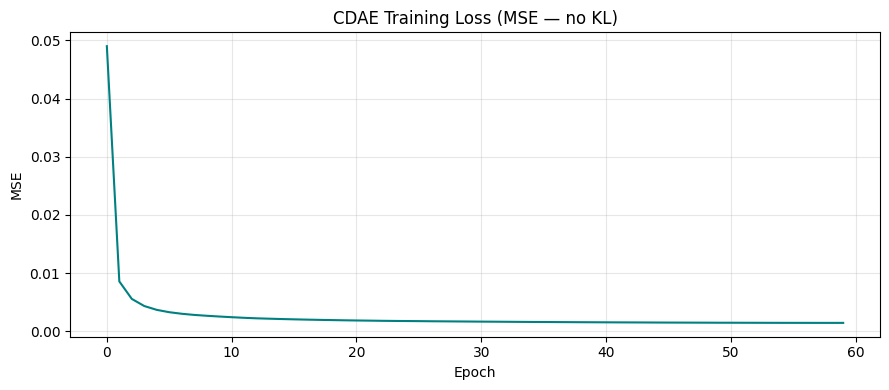

Saved -> cdae_training_loss.png


In [24]:
# ── Sanity check: CDAE loss should decrease monotonically ───────────────
losses_arr = np.array(cdae_losses)
print(f'Loss stats  min={losses_arr.min():.6f}  max={losses_arr.max():.6f}  '
      f'final={losses_arr[-1]:.6f}')
print(f'Any NaN: {np.isnan(losses_arr).any()}   Any Inf: {np.isinf(losses_arr).any()}')

# Check monotonic trend in second half (first half may still be warmup)
second_half = losses_arr[len(losses_arr)//2:]
is_trending_down = second_half[-1] < second_half[0]
print(f'Second-half trend: {"decreasing (good)" if is_trending_down else "WARNING: not decreasing"}')

# Visualise
plt.figure(figsize=(9, 4))
plt.plot(losses_arr, color='teal', linewidth=1.5)
plt.title('CDAE Training Loss (MSE — no KL)', fontsize=12)
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/cdae_training_loss.png', dpi=150)
plt.show()
print('Saved -> cdae_training_loss.png')


In [25]:
# ── Quality-Aware Sample Filtering ──────────────────────────────────────
# For each real sample, compute reconstruction error under the CDAE.
# Per class: tau_c = mean(recon_error) + std(recon_error)
# Generated samples with error < tau_c are admitted to training.

cdae.eval()
class_thresholds = {}

print('Computing per-class reconstruction error thresholds ...')
print(f'  {"Class":<25}  {"n":>8}  {"mean_err":>9}  {"std_err":>9}  {"tau":>9}')
print('  ' + '-'*65)

with torch.no_grad():
    for cls_idx in range(NUM_CLASSES):
        mask  = (y_train == cls_idx)
        X_cls = torch.FloatTensor(
            np.clip(X_train_sc[mask], -CLIP_FEAT, CLIP_FEAT).astype(np.float32)
        ).to(device)
        c_oh = F.one_hot(
            torch.full((X_cls.size(0),), cls_idx, dtype=torch.long), NUM_CLASSES
        ).float().to(device)

        # Use training=False so no noise is added during threshold computation
        x_hat, _ = cdae(X_cls, c_oh, training=False)
        errors = F.mse_loss(x_hat, X_cls, reduction='none').mean(dim=1).cpu().numpy()
        tau = float(errors.mean() + errors.std())
        class_thresholds[cls_idx] = tau
        print(f'  {class_names[cls_idx]:<25}  {mask.sum():>8,}  '
              f'{errors.mean():>9.5f}  {errors.std():>9.5f}  {tau:>9.5f}')

print('\nThresholds set.')


Computing per-class reconstruction error thresholds ...
  Class                             n   mean_err    std_err        tau
  -----------------------------------------------------------------
  Benign                      129,336    0.00433    0.01994    0.02427
  Brute Force Attack            2,115    0.00882    0.04392    0.05274
  DDoS Attack                3,576,052    0.00028    0.00349    0.00377
  DoS Attack                  950,846    0.00042    0.00502    0.00544
  Mirai Attack                309,825    0.00087    0.00491    0.00577
  Recon Attack                 41,611    0.00400    0.01702    0.02102
  Spoofing Attack              57,572    0.00671    0.04609    0.05280
  Web Attack                    1,593    0.00369    0.00812    0.01181

Thresholds set.


In [26]:
# ── Generate & Filter Synthetic Samples ─────────────────────────────────
class_counts = Counter(y_train.tolist())
median_count = int(np.median(list(class_counts.values())))
print(f'Median class count (augmentation target): {median_count:,}')
print()

GEN_BATCH = 4096
X_synth_list = []
y_synth_list = []

cdae.eval()
with torch.no_grad():
    for cls_idx in range(NUM_CLASSES):
        n_real = class_counts[cls_idx]
        n_need = max(0, median_count - n_real)
        if n_need == 0:
            print(f'  {class_names[cls_idx]:<25} — no augmentation needed ({n_real:,} samples)')
            continue

        tau = class_thresholds[cls_idx]
        c_idx_t = torch.tensor([cls_idx], dtype=torch.long)
        accepted_chunks, n_accepted, n_generated = [], 0, 0

        for _ in range(30):   # max 30 rounds
            if n_accepted >= n_need:
                break
            batch = min(GEN_BATCH, (n_need - n_accepted) * 4)

            # Generate: sample z in bottleneck space, decode with class condition
            x_gen = cdae.generate(batch, cls_idx, NUM_CLASSES, device,
                                   gen_sigma=CDAE_GEN_SIGMA)

            # Quality gate: re-encode x_gen (no noise) and check recon error
            c = F.one_hot(c_idx_t.expand(batch), NUM_CLASSES).float().to(device)
            x_hat2, _ = cdae(x_gen, c, training=False)
            err = F.mse_loss(x_hat2, x_gen, reduction='none').mean(dim=1)
            good = (err < tau).cpu()

            chunk = x_gen[good.to(device)].cpu().numpy()
            accepted_chunks.append(chunk)
            n_accepted  += len(chunk)
            n_generated += batch

        if accepted_chunks:
            X_cls_synth = np.vstack(accepted_chunks)[:n_need]
            X_synth_list.append(X_cls_synth)
            y_synth_list.append(np.full(len(X_cls_synth), cls_idx, dtype=np.int64))
            rate = n_accepted / max(n_generated, 1) * 100
            print(f'  {class_names[cls_idx]:<25}  need={n_need:>7,}  '
                  f'added={len(X_cls_synth):>7,}  gen={n_generated:>8,}  '
                  f'accept={rate:.1f}%')
        else:
            print(f'  {class_names[cls_idx]:<25} WARNING: 0 accepted — skipping')

print('\nSynthetic generation complete.')


Median class count (augmentation target): 93,454

  Benign                    — no augmentation needed (129,336 samples)
  Brute Force Attack         need= 91,339  added=     13  gen= 122,880  accept=0.0%
  DDoS Attack               — no augmentation needed (3,576,052 samples)
  DoS Attack                — no augmentation needed (950,846 samples)
  Mirai Attack              — no augmentation needed (309,825 samples)
  Recon Attack               need= 51,843  added=      0  gen= 122,880  accept=0.0%
  Spoofing Attack            need= 35,882  added=      4  gen= 122,880  accept=0.0%
  Web Attack                 need= 91,861  added=      0  gen= 122,880  accept=0.0%

Synthetic generation complete.


In [27]:
# ── Merge real + synthetic training data ────────────────────────────────
if X_synth_list:
    X_synth = np.vstack(X_synth_list)
    y_synth = np.concatenate(y_synth_list)
    X_train_aug = np.vstack([X_train_sc, X_synth])
    y_train_aug = np.concatenate([y_train, y_synth])
else:
    X_train_aug = X_train_sc.copy()
    y_train_aug = y_train.copy()

# Shuffle
perm = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]
y_train_aug = y_train_aug[perm]

print(f'Augmented train set: {X_train_aug.shape}')
print('\nClass distribution after QA-CVAE augmentation:')
for cls, cnt in zip(class_names, np.bincount(y_train_aug)):
    print(f'  {cls:<25} {cnt:>8,}')

Augmented train set: (5068967, 46)

Class distribution after QA-CVAE augmentation:
  Benign                     129,336
  Brute Force Attack           2,128
  DDoS Attack               3,576,052
  DoS Attack                 950,846
  Mirai Attack               309,825
  Recon Attack                41,611
  Spoofing Attack             57,576
  Web Attack                   1,593


## Step 9 — Enhancement 2: AE-LSTM + Attention Architecture

Architecture: `AE (parallel) + LSTM` → `Concatenate` → `Self-Attention` → `Dense` → `Softmax`

In [28]:
# ── Scaled Dot-Product Self-Attention ───────────────────────────────────
class SelfAttention(nn.Module):
    """
    Single-head self-attention over the feature dimension.
    Input shape: (batch, seq_len, d_model)
    Returns attended output of same shape.
    """
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.scale = d_model ** -0.5
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout  = nn.Dropout(dropout)
        self.norm     = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (batch, seq, d)
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        attn_weights = torch.softmax(Q @ K.transpose(-2, -1) * self.scale, dim=-1)
        attn_weights = self.dropout(attn_weights)
        attended = attn_weights @ V
        out = self.out_proj(attended)
        return self.norm(out + x)  # residual + layer norm


# ── Full Improved Model: AE-LSTM + Attention ────────────────────────────
class ImprovedIDS(nn.Module):
    """
    Improved architecture replacing CNN with Self-Attention.

    Pipeline:
      Input (batch, seq=1, input_dim)
        ├── AE branch: Dense -> BN -> LeakyReLU -> bottleneck -> Dense -> BN -> LeakyReLU
        └── LSTM branch: LSTM(tanh) -> Dense
      Concatenate AE + LSTM outputs along feature dim
      Self-Attention (residual + layernorm)
      Global avg pool over sequence dim (reduces seq=1 -> scalar features)
      Dense -> BatchNorm -> LeakyReLU -> Dropout -> Output -> Softmax
    """
    def __init__(self, input_dim, num_classes,
                 bottleneck_ratio=0.5,
                 lstm_hidden=None,
                 attn_heads=1,
                 dropout=0.3):
        super().__init__()
        bottleneck = max(4, round(input_dim * bottleneck_ratio))
        if lstm_hidden is None:
            lstm_hidden = bottleneck

        # ── AE branch ──────────────────────────────────────────────────
        self.ae_encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.LeakyReLU(0.2),
        )
        self.ae_bottleneck = nn.Linear(input_dim, bottleneck)
        self.ae_decoder = nn.Sequential(
            nn.Linear(bottleneck, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.LeakyReLU(0.2),
        )

        # ── LSTM branch ────────────────────────────────────────────────
        # Input shape to LSTM: (batch, seq=1, input_dim)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            dropout=0.0
        )
        self.lstm_proj = nn.Linear(lstm_hidden, input_dim)

        # ── Attention ──────────────────────────────────────────────────
        # After concat, feature dim = input_dim (AE) + input_dim (LSTM) = 2*input_dim
        # We treat this as a sequence of length 1, dim=2*input_dim
        attn_dim = 2 * input_dim
        self.attention = SelfAttention(attn_dim, dropout=dropout)

        # ── Classifier head ────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(attn_dim, bottleneck * 2),
            nn.BatchNorm1d(bottleneck * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout),
            nn.Linear(bottleneck * 2, num_classes),
        )

    def forward(self, x):
        # x: (batch, input_dim)  — flat features
        batch = x.size(0)

        # ── AE branch ──────────────────────────────────────────────────
        enc  = self.ae_encoder(x)
        btn  = self.ae_bottleneck(enc)
        ae_out = self.ae_decoder(btn)          # (batch, input_dim)

        # ── LSTM branch ────────────────────────────────────────────────
        x_seq = x.unsqueeze(1)                 # (batch, 1, input_dim)
        lstm_raw, _ = self.lstm(x_seq)         # (batch, 1, lstm_hidden)
        lstm_out = self.lstm_proj(
            lstm_raw.squeeze(1)                # (batch, lstm_hidden)
        )                                      # (batch, input_dim)

        # ── Concatenate ────────────────────────────────────────────────
        merged = torch.cat([ae_out, lstm_out], dim=1)  # (batch, 2*input_dim)

        # ── Attention (treat merged as seq of len 1) ───────────────────
        merged_seq = merged.unsqueeze(1)       # (batch, 1, 2*input_dim)
        attn_out   = self.attention(merged_seq)  # (batch, 1, 2*input_dim)
        attn_flat  = attn_out.squeeze(1)       # (batch, 2*input_dim)

        # ── Output ─────────────────────────────────────────────────────
        logits = self.classifier(attn_flat)
        return logits


# Quick shape test
with torch.no_grad():
    _test_model = ImprovedIDS(INPUT_DIM, NUM_CLASSES).to(device)
    _dummy = torch.randn(4, INPUT_DIM).to(device)
    _out = _test_model(_dummy)
    print(f'Model output shape: {_out.shape}  (expected: [4, {NUM_CLASSES}])')

total_params = sum(p.numel() for p in _test_model.parameters())
print(f'Total parameters  : {total_params:,}')
del _test_model, _dummy, _out

Model output shape: torch.Size([4, 8])  (expected: [4, 8])
Total parameters  : 51,321


## Step 10 — DataLoaders

In [29]:
BATCH_SIZE = 4096   # Large batch fits T4 16 GB VRAM well

# Augmented training set
X_tr_t = torch.FloatTensor(X_train_aug)
y_tr_t = torch.LongTensor(y_train_aug)
train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)

# Split augmented train into train / val (80/20 of augmented)
n_val = int(0.20 * len(train_ds))
n_tr  = len(train_ds) - n_val
tr_sub, val_sub = torch.utils.data.random_split(
    train_ds, [n_tr, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
tr_loader  = DataLoader(tr_sub,  batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True)
val_loader = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

# Test set (original, no augmentation)
X_te_t = torch.FloatTensor(X_test_sc)
y_te_t = torch.LongTensor(y_test)
test_ds     = TensorDataset(X_te_t, y_te_t)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f'Train sub-loader  : {len(tr_sub):,} samples')
print(f'Val sub-loader    : {len(val_sub):,} samples')
print(f'Test loader       : {len(test_ds):,} samples')

Train sub-loader  : 4,055,174 samples
Val sub-loader    : 1,013,793 samples
Test loader       : 2,172,408 samples


## Step 11 — Instantiate Model, Optimizer, Scheduler

In [30]:
model = ImprovedIDS(
    input_dim=INPUT_DIM,
    num_classes=NUM_CLASSES,
    bottleneck_ratio=0.5,
    dropout=0.3
).to(device)

# Class-weighted loss to handle any remaining imbalance
class_counts_aug = np.bincount(y_train_aug)
weights = 1.0 / (class_counts_aug + 1e-6)
weights = weights / weights.sum() * NUM_CLASSES
class_weights = torch.FloatTensor(weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9,
                      weight_decay=1e-4, nesterov=True)

EPOCHS = 100
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(f'Training for {EPOCHS} epochs  |  batch={BATCH_SIZE}  |  device={device}')
print(f'Optimizer: SGD  lr=0.01  momentum=0.9  nesterov=True')
print(f'Scheduler: CosineAnnealingLR  T_max={EPOCHS}')

Model parameters: 51,321
Training for 100 epochs  |  batch=4096  |  device=cuda
Optimizer: SGD  lr=0.01  momentum=0.9  nesterov=True
Scheduler: CosineAnnealingLR  T_max=100


## Step 12 — Training Loop

In [31]:
def run_epoch(loader, model, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            preds       = logits.argmax(1)
            correct    += (preds == yb).sum().item()
            total      += xb.size(0)
    return total_loss / total, correct / total


# ── Training ────────────────────────────────────────────────────────────
tr_losses, tr_accs, vl_losses, vl_accs = [], [], [], []
best_val_acc = 0.0
best_state   = None

print(f'{'Epoch':>6}  {'Tr Loss':>9}  {'Tr Acc':>7}  {'Vl Loss':>9}  {'Vl Acc':>7}  {'LR':>8}')
print('-' * 60)

t_start = time.time()
for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(tr_loader, model, criterion, optimizer, train=True)
    vl_loss, vl_acc = run_epoch(val_loader, model, criterion, train=False)
    scheduler.step()

    tr_losses.append(tr_loss)
    tr_accs.append(tr_acc)
    vl_losses.append(vl_loss)
    vl_accs.append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    if ep % 10 == 0 or ep == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'{ep:>6}  {tr_loss:>9.5f}  {tr_acc*100:>6.2f}%  '
              f'{vl_loss:>9.5f}  {vl_acc*100:>6.2f}%  {lr_now:.2e}')

    if ep % 20 == 0:
        torch.save({
            'epoch': ep,
            'model_state': best_state,
            'class_names': class_names,
            'input_dim':   INPUT_DIM,
            'num_classes': NUM_CLASSES,
        }, f'/kaggle/working/improved_checkpoint_ep{ep}.pth')

elapsed = time.time() - t_start
print(f'\nTraining complete in {elapsed/60:.1f} min')
print(f'Best validation accuracy: {best_val_acc*100:.2f}%')

 Epoch    Tr Loss   Tr Acc    Vl Loss   Vl Acc        LR
------------------------------------------------------------
     1    0.93152   66.62%    0.74207   71.43%  1.00e-02
    10    0.69885   74.36%    0.69504   66.06%  9.76e-03
    20    0.64809   81.13%    0.67516   68.38%  9.05e-03
    30    0.60803   86.43%    0.59995   82.92%  7.94e-03
    40    0.57703   90.24%    0.63839   70.46%  6.55e-03
    50    0.55304   93.58%    0.54168   96.50%  5.01e-03
    60    0.52602   96.56%    0.53966   91.20%  3.46e-03
    70    0.50774   97.72%    0.52266   95.62%  2.07e-03
    80    0.49025   98.13%    0.50175   98.30%  9.64e-04
    90    0.47795   98.32%    0.53874   85.98%  2.54e-04
   100    0.47146   98.38%    0.50063   98.26%  1.00e-05

Training complete in 67.4 min
Best validation accuracy: 98.48%


## Step 13 — Training Curves

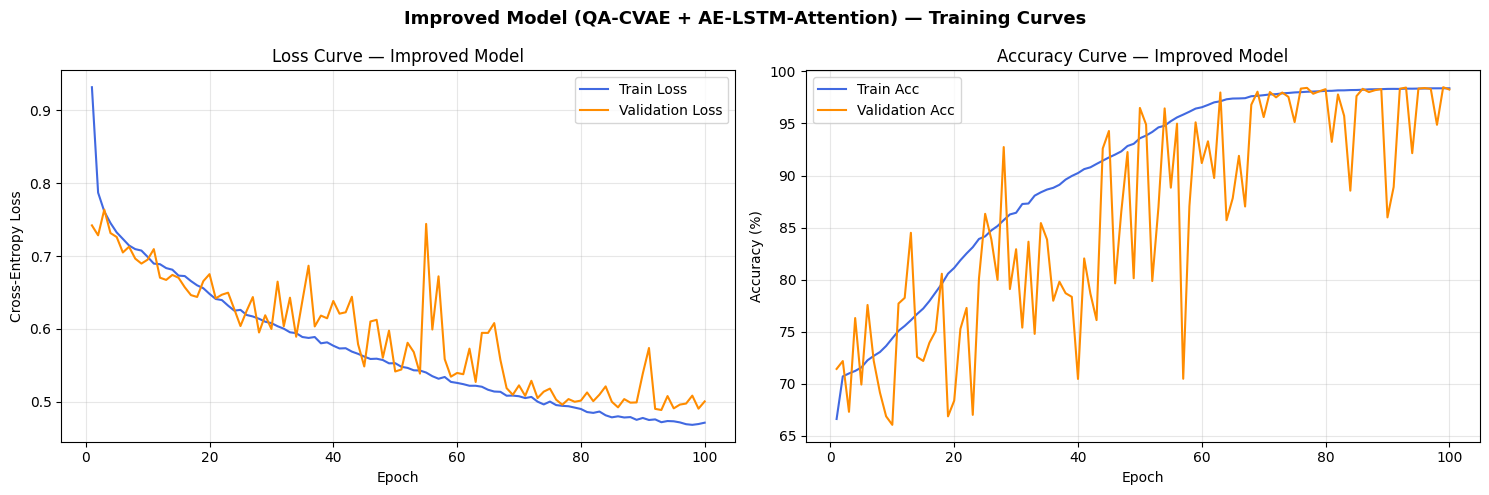

Saved -> improved_training_curves.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs_x = range(1, len(tr_losses) + 1)

axes[0].plot(epochs_x, tr_losses, label='Train Loss',      color='royalblue')
axes[0].plot(epochs_x, vl_losses, label='Validation Loss', color='darkorange')
axes[0].set(title='Loss Curve — Improved Model',
            xlabel='Epoch', ylabel='Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, [a*100 for a in tr_accs], label='Train Acc',      color='royalblue')
axes[1].plot(epochs_x, [a*100 for a in vl_accs], label='Validation Acc', color='darkorange')
axes[1].set(title='Accuracy Curve — Improved Model',
            xlabel='Epoch', ylabel='Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Improved Model (QA-CVAE + AE-LSTM-Attention) — Training Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/improved_training_curves.png', dpi=150)
plt.show()
print('Saved -> improved_training_curves.png')

## Step 14 — CVAE Training Loss Curve

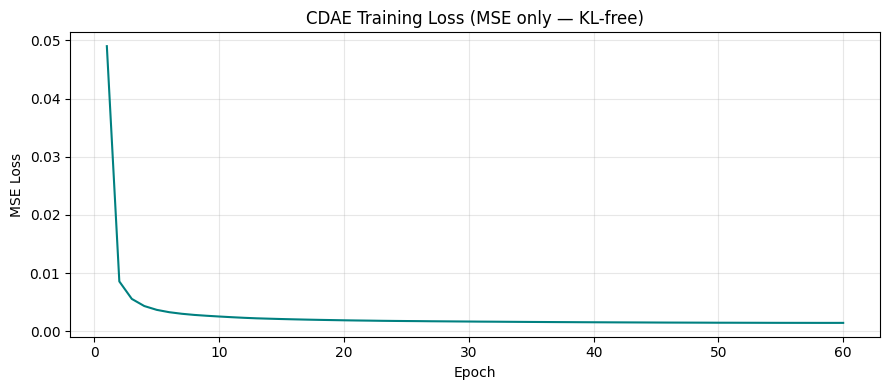

Saved -> cvae_training_loss.png


In [33]:
# ── CDAE Training Loss Curve ────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cdae_losses)+1), cdae_losses, color='teal', linewidth=1.5)
plt.title('CDAE Training Loss (MSE only — KL-free)', fontsize=12)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/cvae_training_loss.png', dpi=150)
plt.show()
print('Saved -> cvae_training_loss.png')


## Step 15 — Final Evaluation on Test Set

In [34]:
def full_evaluate(model, loader):
    model.eval()
    y_true_all, y_pred_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb).argmax(1).cpu().numpy()
            y_pred_all.extend(preds.tolist())
            y_true_all.extend(yb.numpy().tolist())
    return np.array(y_true_all), np.array(y_pred_all)


# Load best weights
model.load_state_dict(best_state)
y_true, y_pred = full_evaluate(model, test_loader)

acc  = accuracy_score(y_true,  y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true,    y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true,        y_pred, average='weighted', zero_division=0)

print('=' * 65)
print('       IMPROVED MODEL — OVERALL RESULTS')
print('=' * 65)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1 Score  : {f1*100:.2f}%')
print('=' * 65)
print()
print('  BASE PAPER REPORTED:')
print('  Accuracy: 99.15% | Precision: 99.39% | Recall: 99.00% | F1: 99.19%')

       IMPROVED MODEL — OVERALL RESULTS
  Accuracy  : 98.48%
  Precision : 98.89%
  Recall    : 98.48%
  F1 Score  : 98.66%

  BASE PAPER REPORTED:
  Accuracy: 99.15% | Precision: 99.39% | Recall: 99.00% | F1: 99.19%


## Step 16 — Per-Class Results

In [35]:
cm      = confusion_matrix(y_true, y_pred)
pc_acc  = cm.diagonal() / cm.sum(axis=1)
pc_prec = precision_score(y_true, y_pred, average=None, zero_division=0)
pc_rec  = recall_score(y_true,    y_pred, average=None, zero_division=0)
pc_f1   = f1_score(y_true,        y_pred, average=None, zero_division=0)

# Base paper per-class numbers for comparison
base_paper = {
    'Benign':             (99.95, 99.96, 99.97, 99.97),
    'Brute Force Attack': (99.57, 75.58, 64.19, 69.42),
    'DDoS Attack':        (99.39, 82.91, 93.26, 87.78),
    'DoS Attack':         (99.97, 99.95, 99.91, 99.93),
    'Mirai Attack':       (99.99, 99.98, 99.97, 99.98),
    'Recon Attack':       (99.98, 98.48, 14.38, 25.10),
    'Spoofing Attack':    (99.95, 61.64,  5.33,  9.81),
    'Web Attack':         (99.49, 78.58, 70.64, 74.40),
}

print('YOUR RESULTS (Improved Model):')
print(f'  {"Class":<25} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7}')
print('  ' + '-' * 57)
for i, cls in enumerate(class_names):
    print(f'  {cls:<25} '
          f'{pc_acc[i]*100:>6.2f}% '
          f'{pc_prec[i]*100:>6.2f}% '
          f'{pc_rec[i]*100:>6.2f}% '
          f'{pc_f1[i]*100:>6.2f}%')
print('  ' + '-' * 57)
print(f'  {"Overall (weighted)":<25} '
      f'{acc*100:>6.2f}% '
      f'{prec*100:>6.2f}% '
      f'{rec*100:>6.2f}% '
      f'{f1*100:>6.2f}%')

print()
print('BASE PAPER REPORTED (Susilo et al. 2025):')
print(f'  {"Class":<25} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7}')
print('  ' + '-' * 57)
for cls, (a, p, r, f) in base_paper.items():
    print(f'  {cls:<25} {a:>6.2f}% {p:>6.2f}% {r:>6.2f}% {f:>6.2f}%')
print('  ' + '-' * 57)
print(f'  {"Overall":<25} {99.15:>6.2f}% {99.39:>6.2f}% {99.00:>6.2f}% {99.19:>6.2f}%')

YOUR RESULTS (Improved Model):
  Class                         Acc    Prec     Rec      F1
  ---------------------------------------------------------
  Benign                     83.44%  90.36%  83.44%  86.76%
  Brute Force Attack         49.12%   7.49%  49.12%  12.99%
  DDoS Attack                99.51%  99.97%  99.51%  99.74%
  DoS Attack                 99.67%  98.94%  99.67%  99.30%
  Mirai Attack               99.51%  99.11%  99.51%  99.31%
  Recon Attack               66.56%  59.65%  66.56%  62.92%
  Spoofing Attack            68.70%  83.49%  68.70%  75.37%
  Web Attack                 69.40%   8.29%  69.40%  14.82%
  ---------------------------------------------------------
  Overall (weighted)         98.48%  98.89%  98.48%  98.66%

BASE PAPER REPORTED (Susilo et al. 2025):
  Class                         Acc    Prec     Rec      F1
  ---------------------------------------------------------
  Benign                     99.95%  99.96%  99.97%  99.97%
  Brute Force Attack      

## Step 17 — Sklearn Classification Report

In [36]:
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

                    precision    recall  f1-score   support

            Benign     0.9036    0.8344    0.8676     55430
Brute Force Attack     0.0749    0.4912    0.1299       906
       DDoS Attack     0.9997    0.9951    0.9974   1532594
        DoS Attack     0.9894    0.9967    0.9930    407505
      Mirai Attack     0.9911    0.9951    0.9931    132783
      Recon Attack     0.5965    0.6656    0.6292     17833
   Spoofing Attack     0.8349    0.6870    0.7537     24674
        Web Attack     0.0829    0.6940    0.1482       683

          accuracy                         0.9848   2172408
         macro avg     0.6841    0.7949    0.6890   2172408
      weighted avg     0.9889    0.9848    0.9866   2172408



## Step 18 — Confusion Matrix

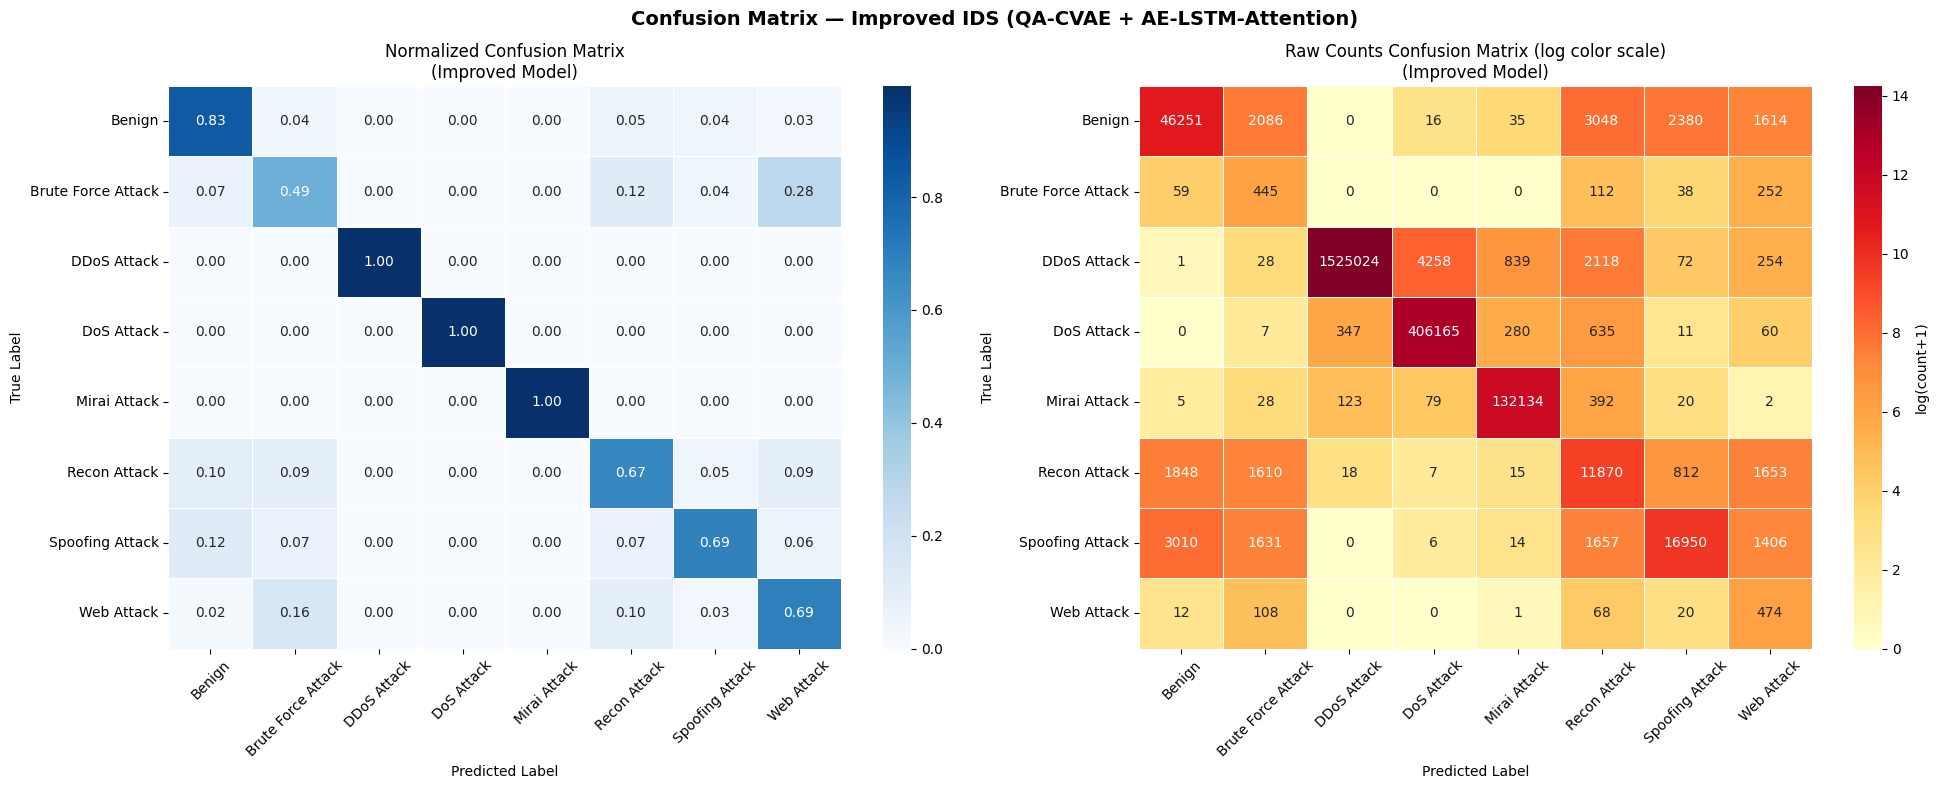

Saved -> improved_confusion_matrix.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Normalized confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Normalized Confusion Matrix\n(Improved Model)', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# Raw counts (log scale for readability)
cm_log = np.log1p(cm.astype(float))
sns.heatmap(cm_log, annot=cm, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'log(count+1)'})
axes[1].set_title('Raw Counts Confusion Matrix (log color scale)\n(Improved Model)', fontsize=12)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrix — Improved IDS (QA-CVAE + AE-LSTM-Attention)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/improved_confusion_matrix.png', dpi=150)
plt.show()
print('Saved -> improved_confusion_matrix.png')

## Step 19 — Per-Class F1 Bar Chart

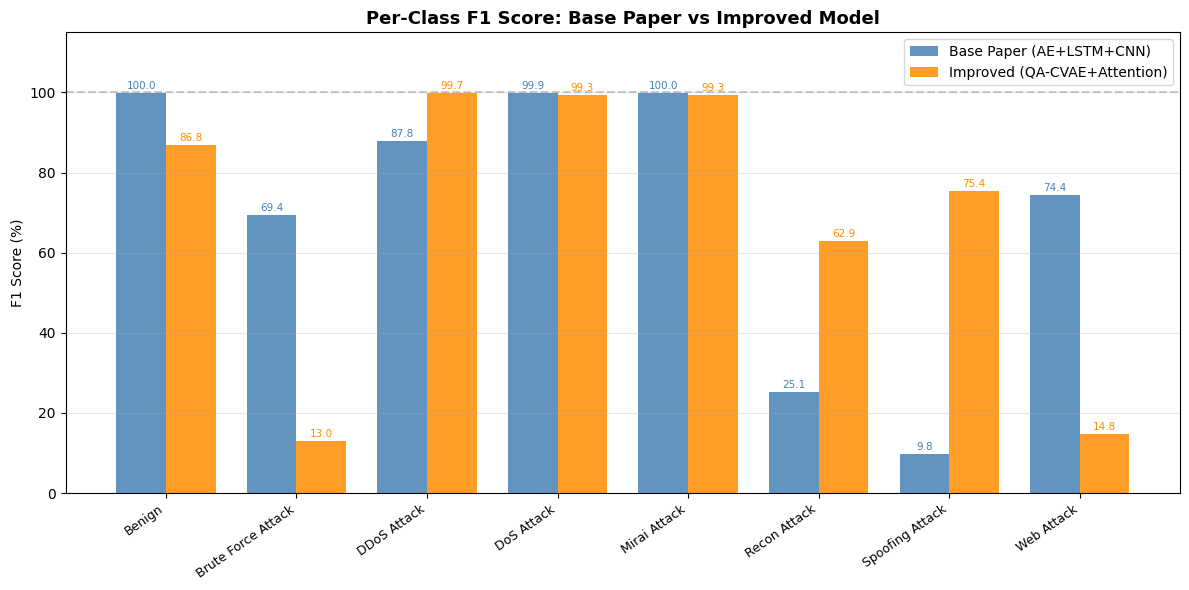

Saved -> improved_f1_comparison.png


In [38]:
fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(class_names))
width  = 0.38

# Base paper F1 values (in same class_names order if available, else fill 0)
base_f1 = [base_paper.get(cls, (0,0,0,0))[3] for cls in class_names]
impr_f1 = [pc_f1[i] * 100 for i in range(len(class_names))]

bars1 = ax.bar(x - width/2, base_f1, width, label='Base Paper (AE+LSTM+CNN)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, impr_f1, width, label='Improved (QA-CVAE+Attention)', color='darkorange', alpha=0.85)

for bar, val in zip(bars1, base_f1):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, color='steelblue')

for bar, val in zip(bars2, impr_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, color='darkorange')

ax.axhline(100, color='gray', linestyle='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('F1 Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Per-Class F1 Score: Base Paper vs Improved Model', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/improved_f1_comparison.png', dpi=150)
plt.show()
print('Saved -> improved_f1_comparison.png')

## Step 20 — Class Imbalance Before/After QA-CVAE

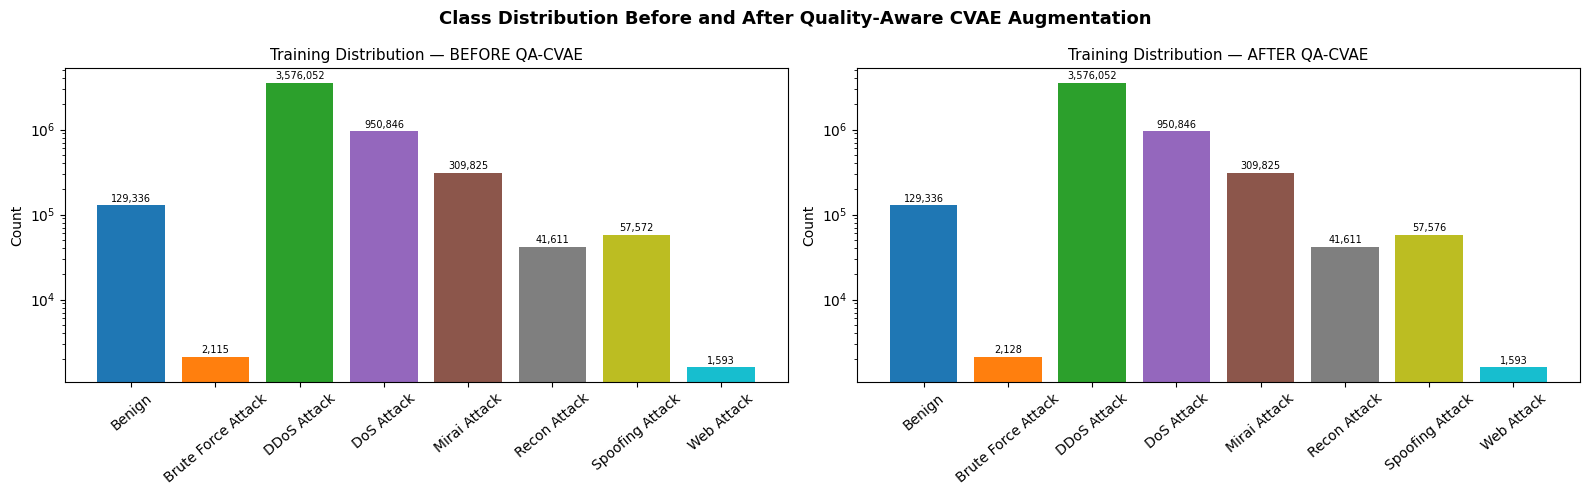

Saved -> class_distribution_augmentation.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

before_counts = [class_counts[i] for i in range(NUM_CLASSES)]
after_counts  = list(np.bincount(y_train_aug))

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

axes[0].bar(class_names, before_counts, color=colors)
axes[0].set_title('Training Distribution — BEFORE QA-CVAE', fontsize=11)
axes[0].set_ylabel('Count'); axes[0].set_yscale('log')
axes[0].tick_params(axis='x', rotation=40)
for i, (cls, cnt) in enumerate(zip(class_names, before_counts)):
    axes[0].text(i, cnt * 1.1, f'{cnt:,}', ha='center', fontsize=7)

axes[1].bar(class_names, after_counts, color=colors)
axes[1].set_title('Training Distribution — AFTER QA-CVAE', fontsize=11)
axes[1].set_ylabel('Count'); axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=40)
for i, (cls, cnt) in enumerate(zip(class_names, after_counts)):
    axes[1].text(i, cnt * 1.1, f'{cnt:,}', ha='center', fontsize=7)

plt.suptitle('Class Distribution Before and After Quality-Aware CVAE Augmentation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution_augmentation.png', dpi=150)
plt.show()
print('Saved -> class_distribution_augmentation.png')

## Step 21 — Comprehensive Comparison Table

In [40]:
comparison_data = {
    'Method': [
        'Al-Haija et al. (IoT-IDCS-CNN)',
        'Wang et al. (DNN-BiLSTM)',
        'Khan et al. (DNN)',
        'Gamage et al. (AE+ANN)',
        'Pektas et al. (CNN-RNN)',
        '** Base Paper (AE+LSTM+CNN) **',
        '** Improved (QA-CVAE+Attention) **',
    ],
    'Dataset': [
        'NSL-KDD', 'CICIoT2023', 'CICIoT2023',
        'CIC-IDS2018', 'CTU-13/ISOT', 'CICIoT2023', 'CICIoT2023'
    ],
    'Acc (%)': [98.20, 93.31, 83.07, 98.22, 99.00, 99.15, acc*100],
    'Prec (%)': ['-',   91.80, 83.62, 97.50, 98.00, 99.39, prec*100],
    'Rec (%)':  ['-',   93.05, 83.07, 98.22, 97.00, 99.00, rec*100],
    'F1 (%)':   ['-',   91.73, 83.00, 97.68, 97.00, 99.19, f1*100],
}

df_comp = pd.DataFrame(comparison_data)

def fmt_val(v):
    if isinstance(v, float):
        return f'{v:.2f}'
    return str(v)

print('\n' + '='*90)
print(f'{'Method':<40} {'Dataset':<14} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}')
print('-'*90)
for _, row in df_comp.iterrows():
    print(f'{row["Method"]:<40} {row["Dataset"]:<14} '
          f'{fmt_val(row["Acc (%)"])  :>7} '
          f'{fmt_val(row["Prec (%)"])  :>7} '
          f'{fmt_val(row["Rec (%)"])  :>7} '
          f'{fmt_val(row["F1 (%)"])   :>7}')
print('='*90)


Method                                   Dataset            Acc    Prec     Rec      F1
------------------------------------------------------------------------------------------
Al-Haija et al. (IoT-IDCS-CNN)           NSL-KDD          98.20       -       -       -
Wang et al. (DNN-BiLSTM)                 CICIoT2023       93.31   91.80   93.05   91.73
Khan et al. (DNN)                        CICIoT2023       83.07   83.62   83.07   83.00
Gamage et al. (AE+ANN)                   CIC-IDS2018      98.22   97.50   98.22   97.68
Pektas et al. (CNN-RNN)                  CTU-13/ISOT      99.00   98.00   97.00   97.00
** Base Paper (AE+LSTM+CNN) **           CICIoT2023       99.15   99.39   99.00   99.19
** Improved (QA-CVAE+Attention) **       CICIoT2023       98.48   98.89   98.48   98.66


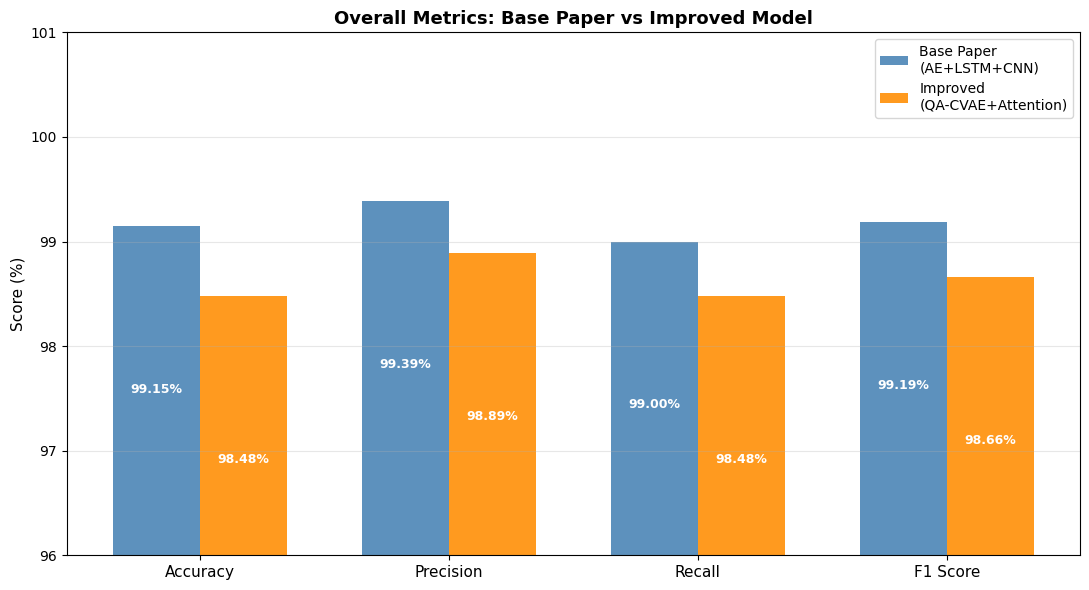

Saved -> overall_comparison_chart.png


In [41]:
# ── Visual comparison bar chart ──────────────────────────────────────────
metrics_compare = {
    'Accuracy':  [99.15, acc*100],
    'Precision': [99.39, prec*100],
    'Recall':    [99.00, rec*100],
    'F1 Score':  [99.19, f1*100],
}
labels = ['Base Paper\n(AE+LSTM+CNN)', 'Improved\n(QA-CVAE+Attention)']

x    = np.arange(len(metrics_compare))
w    = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
bars_b = ax.bar(x - w/2,
                [v[0] for v in metrics_compare.values()],
                w, label=labels[0], color='steelblue', alpha=0.88)
bars_i = ax.bar(x + w/2,
                [v[1] for v in metrics_compare.values()],
                w, label=labels[1], color='darkorange', alpha=0.88)

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f'{bar.get_height():.2f}%', ha='center', va='top',
            fontsize=9, color='white', fontweight='bold')
for bar in bars_i:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f'{bar.get_height():.2f}%', ha='center', va='top',
            fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(list(metrics_compare.keys()), fontsize=11)
ax.set_ylim(96, 101)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Overall Metrics: Base Paper vs Improved Model',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/overall_comparison_chart.png', dpi=150)
plt.show()
print('Saved -> overall_comparison_chart.png')

## Step 22 — Per-Class Precision/Recall/F1 Detailed Chart

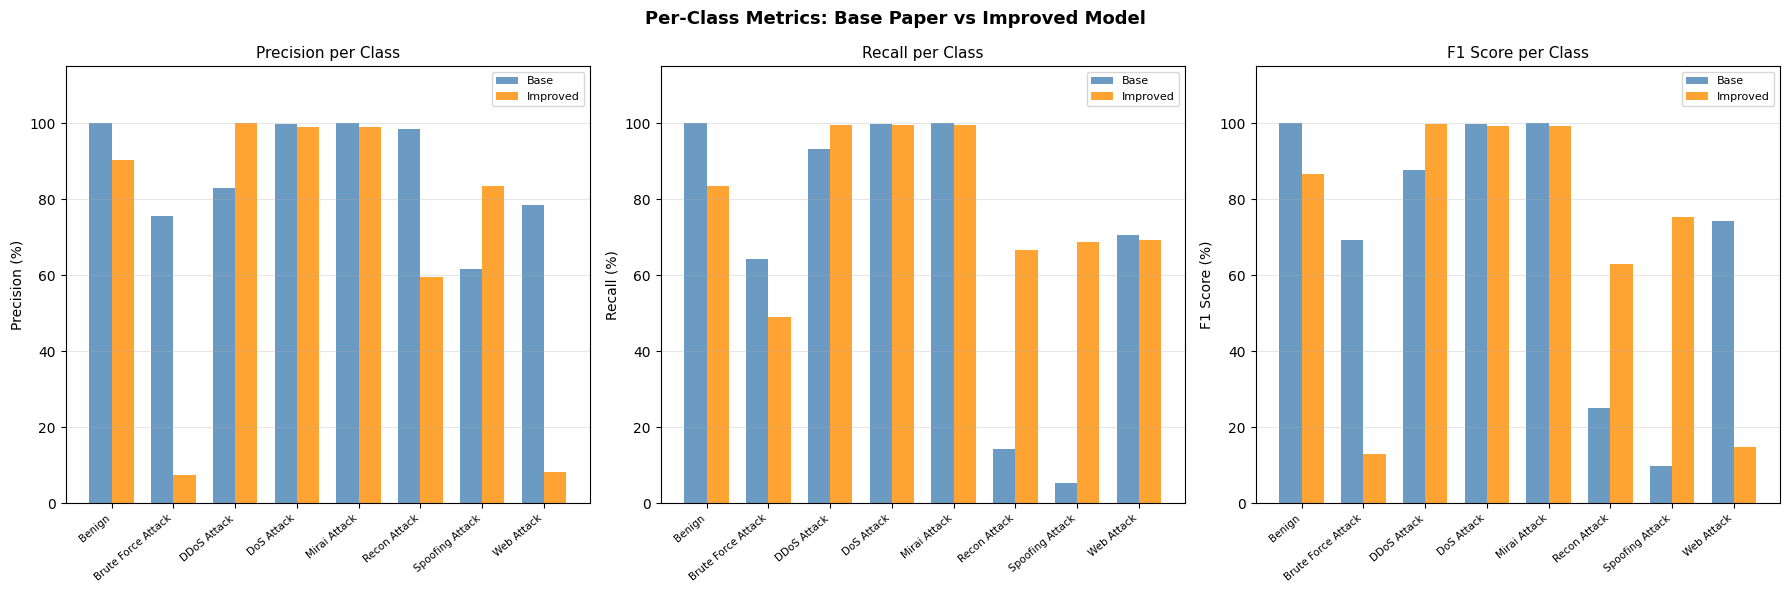

Saved -> perclass_metrics_comparison.png


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_list = [
    ('Precision', pc_prec, [base_paper.get(c, (0,0,0,0))[1] for c in class_names]),
    ('Recall',    pc_rec,  [base_paper.get(c, (0,0,0,0))[2] for c in class_names]),
    ('F1 Score',  pc_f1,   [base_paper.get(c, (0,0,0,0))[3] for c in class_names]),
]

for ax, (metric_name, improved_vals, base_vals) in zip(axes, metrics_list):
    x = np.arange(len(class_names))
    w = 0.36
    ax.bar(x - w/2, base_vals,            w, label='Base',     color='steelblue', alpha=0.8)
    ax.bar(x + w/2, improved_vals * 100,  w, label='Improved', color='darkorange', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=40, ha='right', fontsize=7.5)
    ax.set_ylim(0, 115)
    ax.set_title(f'{metric_name} per Class', fontsize=11)
    ax.set_ylabel(f'{metric_name} (%)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Per-Class Metrics: Base Paper vs Improved Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/perclass_metrics_comparison.png', dpi=150)
plt.show()
print('Saved -> perclass_metrics_comparison.png')

## Step 23 — Save Full Results to JSON

In [43]:
results = {
    'model': 'QA-CVAE + AE-LSTM-Attention',
    'dataset': 'CICIoT2023',
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'input_dim': INPUT_DIM,
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'overall': {
        'accuracy':  float(acc),
        'precision': float(prec),
        'recall':    float(rec),
        'f1':        float(f1),
    },
    'per_class': {
        class_names[i]: {
            'accuracy':  float(pc_acc[i]),
            'precision': float(pc_prec[i]),
            'recall':    float(pc_rec[i]),
            'f1':        float(pc_f1[i]),
        }
        for i in range(len(class_names))
    },
    'base_paper_comparison': {
        'base_acc':  99.15,
        'base_prec': 99.39,
        'base_rec':  99.00,
        'base_f1':   99.19,
        'delta_acc':  round(acc*100 - 99.15, 3),
        'delta_prec': round(prec*100 - 99.39, 3),
        'delta_rec':  round(rec*100 - 99.00, 3),
        'delta_f1':   round(f1*100 - 99.19, 3),
    },
    'training_history': {
        'tr_losses': [float(x) for x in tr_losses],
        'tr_accs':   [float(x) for x in tr_accs],
        'vl_losses': [float(x) for x in vl_losses],
        'vl_accs':   [float(x) for x in vl_accs],
        'best_val_acc': float(best_val_acc),
    }
}

with open('/kaggle/working/improved_results.json', 'w') as fp:
    json.dump(results, fp, indent=2)

print('Saved -> /kaggle/working/improved_results.json')
print()
print('=== DELTA vs BASE PAPER ===')
print(f'  Accuracy  : {results["base_paper_comparison"]["delta_acc"]:+.3f}%')
print(f'  Precision : {results["base_paper_comparison"]["delta_prec"]:+.3f}%')
print(f'  Recall    : {results["base_paper_comparison"]["delta_rec"]:+.3f}%')
print(f'  F1 Score  : {results["base_paper_comparison"]["delta_f1"]:+.3f}%')

Saved -> /kaggle/working/improved_results.json

=== DELTA vs BASE PAPER ===
  Accuracy  : -0.673%
  Precision : -0.499%
  Recall    : -0.523%
  F1 Score  : -0.534%


## Step 24 — Save Final Model

In [44]:
torch.save({
    'model_state_dict': best_state,
    'input_dim':    INPUT_DIM,
    'num_classes':  NUM_CLASSES,
    'class_names':  class_names,
    'overall_metrics': results['overall'],
}, '/kaggle/working/improved_model_FINAL.pth')

torch.save({
    'model_state_dict': cdae.state_dict(),
    'input_dim':    INPUT_DIM,
    'num_classes':  NUM_CLASSES,
    'bottleneck_dim': CDAE_BOTTLENECK,
    'hidden_dim':     CDAE_HIDDEN,
    'thresholds':     class_thresholds,
    'class_names':  class_names,
}, '/kaggle/working/cdae_FINAL.pth')

print('Saved -> /kaggle/working/improved_model_FINAL.pth')
print('Saved -> /kaggle/working/cdae_FINAL.pth')

print('\n' + '='*65)
print('  IMPROVED MODEL — TRAINING COMPLETE')
print('='*65)
print(f'  Accuracy  : {acc*100:.4f}%')
print(f'  Precision : {prec*100:.4f}%')
print(f'  Recall    : {rec*100:.4f}%')
print(f'  F1 Score  : {f1*100:.4f}%')
print('='*65)

Saved -> /kaggle/working/improved_model_FINAL.pth
Saved -> /kaggle/working/cdae_FINAL.pth

  IMPROVED MODEL — TRAINING COMPLETE
  Accuracy  : 98.4766%
  Precision : 98.8914%
  Recall    : 98.4766%
  F1 Score  : 98.6562%
